In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [34]:
df = pd.read_csv('heart_disease_uci(1).csv')

In [35]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df=df.dropna()

In [38]:
df.isna().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [39]:
subset1=df[['id','age','sex']]
subset2=df[['sex','dataset','cp']]
merged= pd.merge(subset1,subset2,on='sex')
merged.head(200)

,id,age,sex,dataset,cp
0,1,63,Male,Cleveland,typical angina
1,1,63,Male,Cleveland,asymptomatic
2,1,63,Male,Cleveland,asymptomatic
3,1,63,Male,Cleveland,non-anginal
4,1,63,Male,Cleveland,atypical angina
...,...,...,...,...,...
195,1,63,Male,Cleveland,asymptomatic
196,1,63,Male,Cleveland,atypical angina
197,1,63,Male,Cleveland,asymptomatic
198,1,63,Male,Cleveland,typical angina


In [40]:
concat_col= pd.concat([subset1,subset2],axis=1)
concat_row = pd.concat([subset1,subset2],axis=0)
concat_col


,id,age,sex,sex,dataset,cp
0,1,63,Male,Male,Cleveland,typical angina
1,2,67,Male,Male,Cleveland,asymptomatic
2,3,67,Male,Male,Cleveland,asymptomatic
3,4,37,Male,Male,Cleveland,non-anginal
4,5,41,Female,Female,Cleveland,atypical angina
...,...,...,...,...,...,...
299,300,68,Male,Male,Cleveland,asymptomatic
300,301,57,Male,Male,Cleveland,asymptomatic
301,302,57,Female,Female,Cleveland,atypical angina
508,509,47,Male,Male,Hungary,asymptomatic


In [41]:
concat_row

,id,age,sex,dataset,cp
0,1.0,63.0,Male,NaN,NaN
1,2.0,67.0,Male,NaN,NaN
2,3.0,67.0,Male,NaN,NaN
3,4.0,37.0,Male,NaN,NaN
4,5.0,41.0,Female,NaN,NaN
...,...,...,...,...,...
299,NaN,NaN,Male,Cleveland,asymptomatic
300,NaN,NaN,Male,Cleveland,asymptomatic
301,NaN,NaN,Female,Cleveland,atypical angina
508,NaN,NaN,Male,Hungary,asymptomatic


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()


C:\Users\dhanashree\AppData\Local\Temp\ipykernel_4604\2800040115.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = scaler.fit_transform(df[num_cols])


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,-1.596821,0.940446,Male,Cleveland,typical angina,0.749760,-0.262867,True,lv hypertrophy,0.029124,False,1.069475,downsloping,-0.718306,fixed defect,-0.770537
1,-1.586375,1.384143,Male,Cleveland,asymptomatic,1.596354,0.747722,False,lv hypertrophy,-1.790447,True,0.380309,flat,2.487269,normal,0.857665
2,-1.575930,1.384143,Male,Cleveland,asymptomatic,-0.661231,-0.339138,False,lv hypertrophy,-0.880662,True,1.327912,flat,1.418744,reversable defect,0.043564
3,-1.565485,-1.943588,Male,Cleveland,non-anginal,-0.096835,0.061285,False,normal,1.632079,False,2.103224,downsloping,-0.718306,normal,-0.770537
4,-1.555039,-1.499891,Female,Cleveland,atypical angina,-0.096835,-0.815830,False,lv hypertrophy,0.982232,False,0.294163,upsloping,-0.718306,normal,-0.770537


Text(0.5, 1.0, 'BoxPlot')

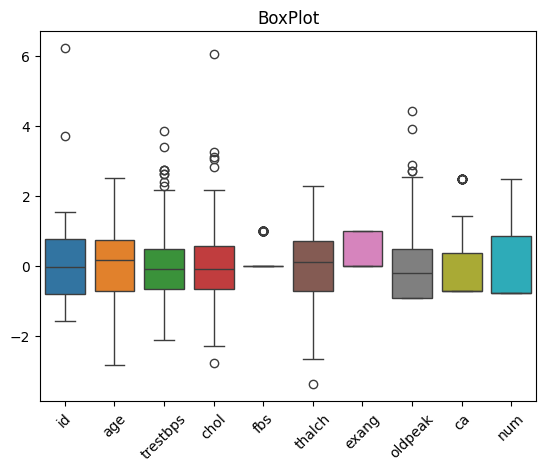

In [43]:
sns.boxplot(df)
plt.xticks(rotation=45)
plt.title('BoxPlot')

In [59]:
def remove_outliers(df,lower=0.25,upper=0.75):
  df = df.copy()
  df_numeric = df.select_dtypes(include=['number']).columns
  for col in df_numeric:
      low=df[col].quantile(lower)
      high=df[col].quantile(upper)
      df = df[(df[col] >= low) & (df[col] <= high)]
  return df.reset_index(drop = True)

In [60]:
cleaned_data = remove_outliers(df)


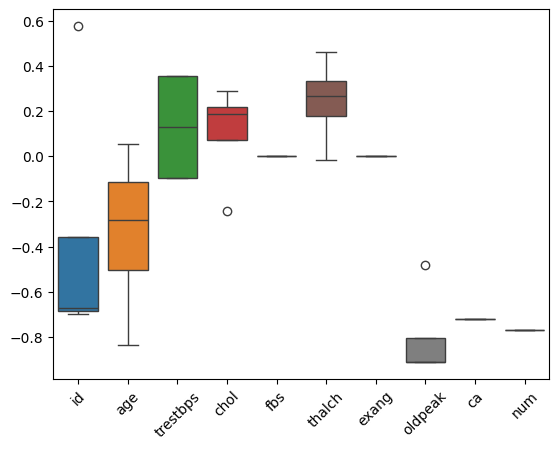

In [61]:
sns.boxplot(cleaned_data)
plt.xticks(rotation=45)
plt.show()